Hierarchical Clustering


Goal: Use agglomerative hierarchical clustering on a customer‑purchasing dataset.
You’ll: scale features → compute/link clusters → plot a dendrogram → choose a cut (k) → assign cluster labels → visualize (PCA 2D) → profile clusters → compare linkages.

In [1]:
# pip install pandas numpy matplotlib seaborn scipy scikit-learn
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [2]:
CSV_PATH = Path('customers.csv')
if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
else:
    n=450
    df = pd.DataFrame({
        'Annual_Spend':  np.r_[np.random.normal(500,90,150),  np.random.normal(1200,160,150), np.random.normal(2200,280,150)].clip(50),
        'Num_Orders':    np.r_[np.random.poisson(7,150),       np.random.poisson(16,150),      np.random.poisson(28,150)],
        'Avg_Basket':    np.r_[np.random.normal(65,10,150),    np.random.normal(90,12,150),    np.random.normal(115,18,150)],
        'RecencyDays':   np.r_[np.random.gamma(3,28,150),      np.random.gamma(2,25,150),      np.random.gamma(1.6,20,150)],
        'ReturnsRate%':  np.r_[np.random.beta(2,18,150),       np.random.beta(2,9,150),        np.random.beta(2,6,150)]*100
    })
num_cols = df.select_dtypes(include='number').columns.tolist()
X = df[num_cols].copy()
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Annual_Spend,450.0,1286.827024,701.911476,270.230917,578.618039,1184.271767,1993.253217,2831.882579
Num_Orders,450.0,17.124444,9.668334,0.000000,9.000000,15.000000,25.000000,43.000000
Avg_Basket,450.0,89.618917,24.704970,34.456695,70.884252,86.714561,106.971938,163.552359
RecencyDays,450.0,58.953483,47.087220,0.399266,23.298294,45.917727,82.792427,281.274775
ReturnsRate%,450.0,17.517733,12.753606,0.674172,7.725250,14.335405,24.970193,61.958038


2) Scale features (distance‑based methods need this)

In [3]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

3) Build hierarchical clustering & dendrogram

Cophenetic correlation: 0.696


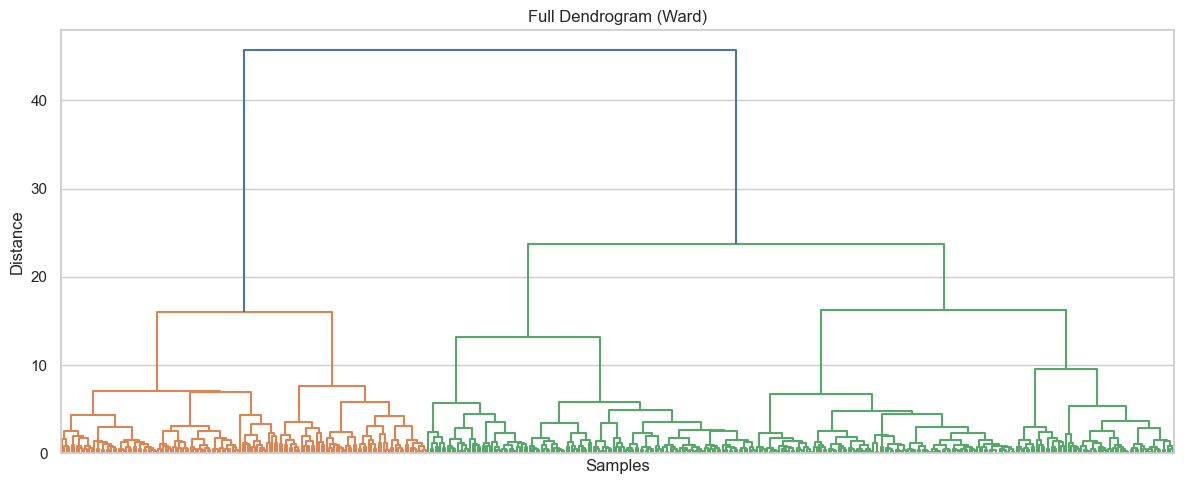

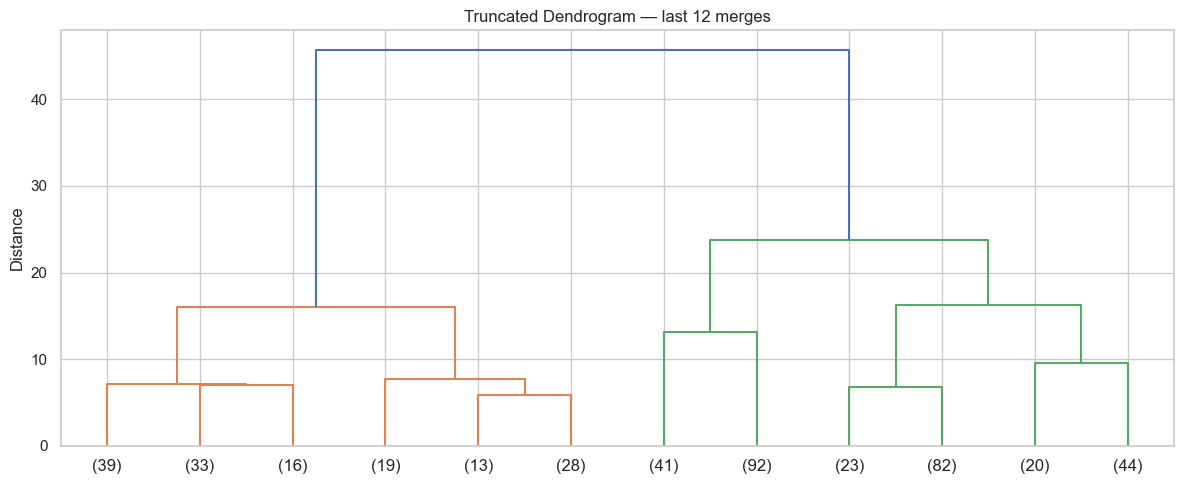

In [4]:
# Pairwise distances (Euclidean)
D = pdist(Xs, metric='euclidean')

# Cophenetic correlation (how faithfully the linkage preserves original distances)
Z = linkage(D, method='ward')          # or linkage(Xs, method='ward', metric='euclidean')
coph_corr, _ = cophenet(Z, D)
print("Cophenetic correlation:", round(coph_corr, 3))

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode=None, p=0, no_labels=True, color_threshold=None)
plt.title('Full Dendrogram (Ward)'); plt.xlabel('Samples'); plt.ylabel('Distance')
plt.tight_layout(); plt.show()

# Truncated view (cleaner): last few merges
plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode='lastp', p=12, show_leaf_counts=True)
plt.title('Truncated Dendrogram — last 12 merges'); plt.ylabel('Distance')
plt.tight_layout(); plt.show()

4) Choose a cut (k) and assign cluster labels

In [5]:
k = 3  # try 3–6
labels = fcluster(Z, t=k, criterion='maxclust')
df_hc = df.copy()
df_hc['cluster'] = labels
df_hc['cluster'].value_counts().sort_index()
print("Silhouette (k-Means proxy on labels):", round(silhouette_score(Xs, labels), 3))

Silhouette (k-Means proxy on labels): 0.3


5) Visualize clusters in PCA 2D

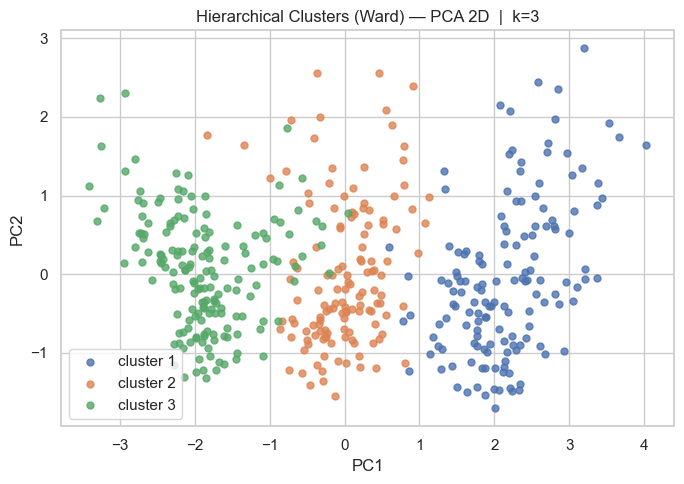

In [6]:
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(Xs)

plt.figure(figsize=(7,5))
for c in np.unique(labels):
    idx = labels == c
    plt.scatter(X2[idx,0], X2[idx,1], s=25, alpha=0.8, label=f'cluster {c}')
plt.title(f'Hierarchical Clusters (Ward) — PCA 2D  |  k={k}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.tight_layout(); plt.show()

6) Cluster profiling (means/medians + sizes)

In [7]:
profile_mean   = df_hc.groupby('cluster')[num_cols].mean().round(2)
profile_median = df_hc.groupby('cluster')[num_cols].median().round(2)
sizes          = df_hc['cluster'].value_counts().sort_index().rename('count')
summary = profile_mean.assign(count=sizes)
summary

,Annual_Spend,Num_Orders,Avg_Basket,RecencyDays,ReturnsRate%,count
cluster,,,,,,
1,2168.79,28.36,116.42,31.81,24.22,148
2,1179.33,15.83,88.09,44.25,19.99,133
3,599.06,8.30,67.35,94.30,9.70,169


Example interpretation:

Cluster 1: High spend/order frequency, low recency → VIPs.

Cluster 2: Low spend, high recency → lapsed.

Cluster 3: Mid spend, higher return rate → return‑prone.

7) Compare linkage methods & metrics
Different linkages change shapes:

ward (min variance; Euclidean only),

average (UPGMA),

complete (max distance; compact clusters),

single (can chain; noisy).



In [8]:
for method in ['ward','average','complete','single']:
    Zm = linkage(Xs, method=method, metric='euclidean')
    labs = fcluster(Zm, t=k, criterion='maxclust')
    sil = silhouette_score(Xs, labs)
    coph, _ = cophenet(Zm, pdist(Xs))
    print(f"{method:8s} | silhouette={sil:.3f} | cophenetic={coph:.3f}")

ward     | silhouette=0.300 | cophenetic=0.696
average  | silhouette=0.326 | cophenetic=0.731
complete | silhouette=0.300 | cophenetic=0.701
single   | silhouette=0.326 | cophenetic=0.443


Visual side‑by‑side (truncated dendrograms):

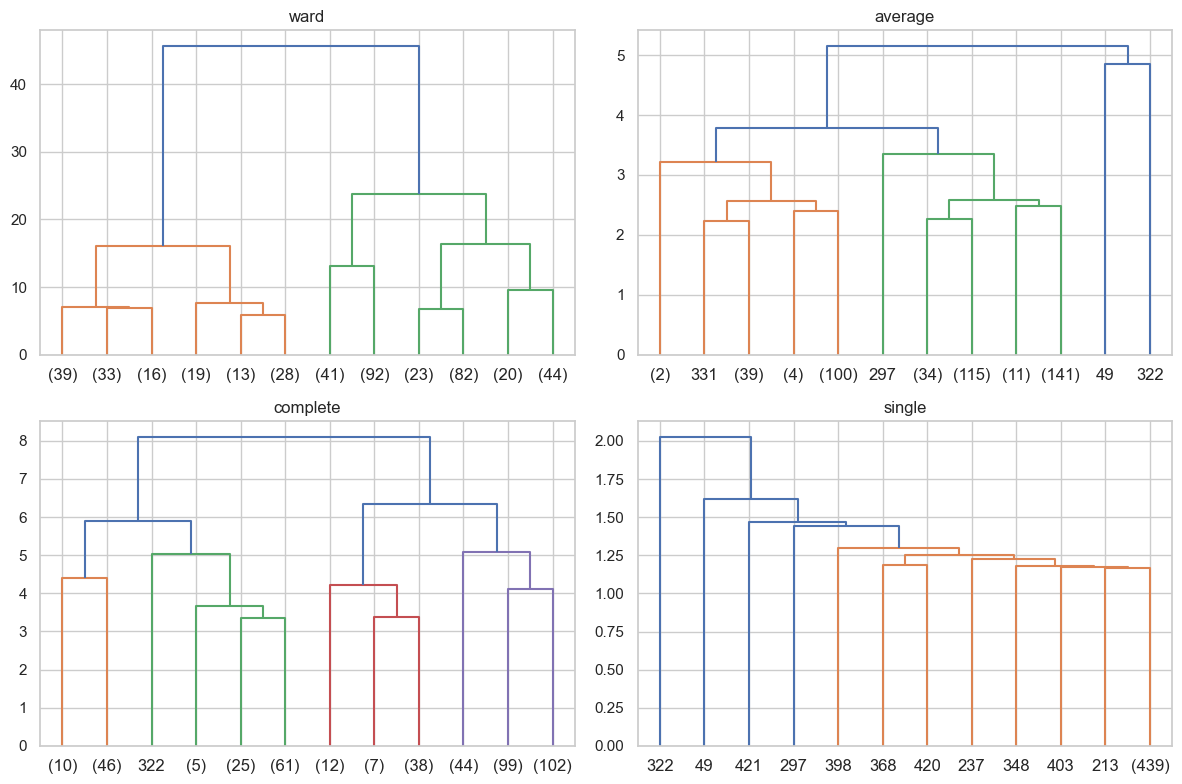

In [9]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
for ax, method in zip(axes.ravel(), ['ward','average','complete','single']):
    Zm = linkage(Xs, method=method)
    dendrogram(Zm, truncate_mode='lastp', p=12, ax=ax)
    ax.set_title(method)
plt.tight_layout(); plt.show()

8) (Optional) Compare to AgglomerativeClustering API + silhouette
If you prefer scikit‑learn’s estimator form:

In [10]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
labs2 = ac.fit_predict(Xs)
print("Sklearn Agglomerative — silhouette:", round(silhouette_score(Xs, labs2), 3))

Sklearn Agglomerative — silhouette: 0.3


9) Save outputs

In [11]:
df_hc.to_csv('customers_hier_clusters.csv', index=False)
summary.to_csv('hier_cluster_profile_summary.csv')
['customers_hier_clusters.csv', 'hier_cluster_profile_summary.csv']

['customers_hier_clusters.csv', 'hier_cluster_profile_summary.csv']

Cut sensitivity: Try k = 3..6. For each, record cluster sizes, silhouette, and a 1‑line business label per cluster. Which k is most actionable?

In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Setup Synthetic Data (Customer Segmentation Context)
# ---------------------------------------------------------
np.random.seed(42)
data = {
    'Income': np.concatenate([
        np.random.normal(30000, 5000, 100),  # Low Income
        np.random.normal(80000, 10000, 100), # Mid Income
        np.random.normal(150000, 20000, 100) # High Income
    ]),
    'Spending_Score': np.concatenate([
        np.random.normal(20, 5, 100),        # Low Spend
        np.random.normal(50, 10, 100),       # Mid Spend
        np.random.normal(90, 5, 100)         # High Spend
    ]),
    'Age': np.random.randint(18, 70, 300)
}
df = pd.DataFrame(data)

# 2. Preprocessing
# ---------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Helper function to generate a 1-line business label
def get_business_label(cluster_df, global_mean):
    """
    Identifies the feature with the largest deviation from the global mean
    to create a simple descriptive label (e.g., "High Income").
    """
    cluster_mean = cluster_df.mean()
    # Calculate % difference from global mean
    diff = (cluster_mean - global_mean) / global_mean
    
    # Find feature with max absolute difference
    max_feat = diff.abs().idxmax()
    direction = "High" if diff[max_feat] > 0 else "Low"
    
    return f"{direction} {max_feat}"

# 3. Cut Sensitivity Analysis (k = 3..6)
# ---------------------------------------------------------
results = []
global_mean = df.mean()

print(f"{'k':<5} | {'Silhouette':<10} | {'Cluster Sizes':<20} | {'Business Labels'}")
print("-" * 80)

best_score = -1
best_k = -1

for k in range(3, 7):
    # "Cut" the tree at k clusters
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_scaled)
    
    # Metrics
    sil_score = silhouette_score(X_scaled, labels)
    
    # Analyze Clusters
    df_temp = df.copy()
    df_temp['Cluster'] = labels
    
    # Get sizes and sort by cluster index
    sizes = df_temp['Cluster'].value_counts().sort_index()
    size_str = str(sizes.tolist())
    
    # Generate Labels per cluster
    cluster_labels = []
    for c_id in range(k):
        c_data = df_temp[df_temp['Cluster'] == c_id]
        label = get_business_label(c_data.drop('Cluster', axis=1), global_mean)
        cluster_labels.append(f"C{c_id}:{label}")
    
    # Formatting output
    print(f"{k:<5} | {sil_score:.4f}     | {size_str:<20} | {', '.join(cluster_labels)}")
    
    # Track best k
    if sil_score > best_score:
        best_score = sil_score
        best_k = k

print("-" * 80)
print(f"Most actionable k (based on Silhouette): k={best_k}")


k     | Silhouette | Cluster Sizes        | Business Labels
--------------------------------------------------------------------------------
3     | 0.4317     | [100, 103, 97]       | C0:High Income, C1:Low Income, C2:Low Income
4     | 0.4001     | [103, 53, 97, 47]    | C0:Low Income, C1:High Income, C2:Low Income, C3:High Income
5     | 0.4125     | [97, 53, 59, 47, 44] | C0:Low Income, C1:High Income, C2:High Age, C3:High Income, C4:Low Income
6     | 0.4523     | [56, 53, 59, 47, 44, 41] | C0:Low Income, C1:High Income, C2:High Age, C3:High Income, C4:Low Income, C5:Low Age
--------------------------------------------------------------------------------
Most actionable k (based on Silhouette): k=6


Linkage sweep: Re‑run profiling for average and complete linkages. Which produces the most interpretable segments (and highest silhouette)?

In [13]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Setup Synthetic Data
# ---------------------------------------------------------
np.random.seed(42)
data = {
    'Income': np.concatenate([
        np.random.normal(30000, 5000, 100),
        np.random.normal(80000, 10000, 100),
        np.random.normal(150000, 20000, 100)
    ]),
    'Spending': np.concatenate([
        np.random.normal(20, 5, 100),
        np.random.normal(50, 10, 100),
        np.random.normal(90, 5, 100)
    ]),
    'Age': np.random.randint(18, 70, 300)
}
df = pd.DataFrame(data)

# 2. Preprocessing
# ---------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
global_mean = df.mean()

def get_business_label(cluster_df, global_mean):
    """Generates a label based on the feature with max deviation from global mean."""
    if len(cluster_df) == 0: return "Empty"
    diff = (cluster_df.mean() - global_mean) / global_mean
    max_feat = diff.abs().idxmax()
    direction = "High" if diff[max_feat] > 0 else "Low"
    return f"{direction} {max_feat}"

# 3. Linkage Sweep (Ward vs Average vs Complete)
# ---------------------------------------------------------
linkages = ['ward', 'average', 'complete']
best_config = {'score': -1, 'desc': '', 'sizes': []}

print(f"{'Linkage':<10} | {'k':<3} | {'Sil.':<6} | {'Cluster Sizes':<20} | {'Business Labels'}")
print("-" * 100)

for linkage in linkages:
    for k in range(3, 7):
        # Fit model with specific linkage
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = model.fit_predict(X_scaled)
        
        # Metrics
        sil = silhouette_score(X_scaled, labels)
        
        # Profiling
        df_temp = df.copy()
        df_temp['Cluster'] = labels
        sizes = df_temp['Cluster'].value_counts().sort_index().tolist()
        
        # Generate Labels
        lbls = []
        for c in range(k):
            c_data = df_temp[df_temp['Cluster'] == c]
            lbls.append(get_business_label(c_data.drop('Cluster', axis=1), global_mean))
        
        # Output Row
        print(f"{linkage:<10} | {k:<3} | {sil:.3f}  | {str(sizes):<20} | {', '.join(lbls)}")
        
        # Logic for "Best": Maximize Silhouette
        if sil > best_config['score']:
            best_config['score'] = sil
            best_config['desc'] = f"Linkage: {linkage}, k={k}"
            best_config['sizes'] = sizes

print("-" * 100)
print(f"Winner (Highest Silhouette): {best_config['desc']} with Score: {best_config['score']:.3f}")

# Heuristic for Interpretability: Check for 'micro-clusters' (often noise in Single/Average linkage)
min_cluster_size = min(best_config['sizes'])
total_rows = len(df)
if min_cluster_size < (total_rows * 0.05):
    print(f"Warning: The winner has a small cluster ({min_cluster_size} items). "
          "This might be an outlier group rather than a market segment.")
else:
    print("The winner has well-balanced cluster sizes (interpretable).")


Linkage    | k   | Sil.   | Cluster Sizes        | Business Labels
----------------------------------------------------------------------------------------------------
ward       | 3   | 0.432  | [100, 103, 97]       | High Income, Low Income, Low Income
ward       | 4   | 0.400  | [103, 53, 97, 47]    | Low Income, High Income, Low Income, High Income
ward       | 5   | 0.413  | [97, 53, 59, 47, 44] | Low Income, High Income, High Age, High Income, Low Income
ward       | 6   | 0.452  | [56, 53, 59, 47, 44, 41] | Low Income, High Income, High Age, High Income, Low Income, Low Age
average    | 3   | 0.412  | [132, 100, 68]       | Low Income, High Income, Low Income
average    | 4   | 0.419  | [100, 77, 68, 55]    | High Income, Low Age, Low Income, Low Income
average    | 5   | 0.426  | [77, 46, 68, 55, 54] | Low Age, High Income, Low Income, Low Income, High Income
average    | 6   | 0.433  | [68, 46, 58, 55, 54, 19] | Low Income, High Income, Low Income, Low Income, High Income, Low

Outlier handling: Winsorize each numeric feature at the 1st/99th percentiles before scaling; re‑fit Ward. Did the dendrogram shape and profiles stabilize?

--- 1. Raw Data Profiles (Affected by Outliers) ---
               Income   Spending        Age
Cluster                                    
0        5.473883e+04  34.756919  45.140704
1        4.750000e+06  50.500000  56.500000
2        1.490906e+05  89.442510  42.774510


--- 2. Winsorized Data Profiles (Stabilized) ---
                Income   Spending        Age
Cluster                                     
0        151436.825363  89.510788  42.693069
1         58541.485782  37.232678  57.692308
2         52060.732314  33.088654  31.530612


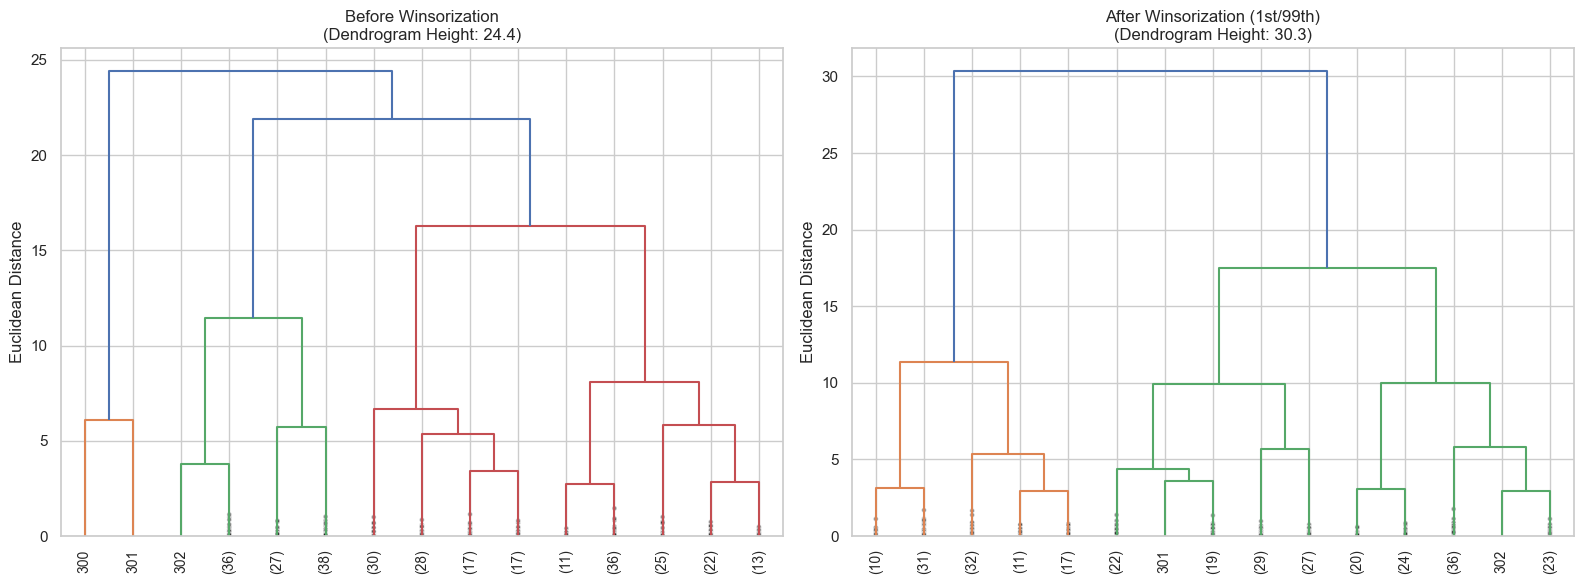


INTERPRETATION:
1. Compare Dendrogram Heights: If 'After' is significantly lower,
   the outliers were stretching the space.
2. Compare Profiles: 'Before' likely has a cluster pulled by the
   5M income outlier. 'After' should show more balanced groups.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# 1. Setup Synthetic Data with Extreme Outliers
# ---------------------------------------------------------
np.random.seed(42)
base_data = {
    'Income': np.concatenate([
        np.random.normal(30000, 5000, 100),
        np.random.normal(80000, 10000, 100),
        np.random.normal(150000, 20000, 100)
    ]),
    'Spending': np.concatenate([
        np.random.normal(20, 5, 100),
        np.random.normal(50, 10, 100),
        np.random.normal(90, 5, 100)
    ]),
    'Age': np.random.randint(18, 70, 300)
}
df_raw = pd.DataFrame(base_data)

# Inject Outliers (The "Whales" that distort clustering)
outliers = pd.DataFrame({
    'Income': [5000000, 4500000, 100],      # Massive income, near zero income
    'Spending': [100, 1, 100],              # Extreme spending behavior
    'Age': [95, 18, 100]
})
df_raw = pd.concat([df_raw, outliers], ignore_index=True)

# 2. Helper: Winsorization Logic
# ---------------------------------------------------------
def winsorize_data(df, lower_p=0.01, upper_p=0.99):
    """Clips values at the 1st and 99th percentiles."""
    df_win = df.copy()
    for col in df_win.select_dtypes(include=[np.number]).columns:
        lower = df_win[col].quantile(lower_p)
        upper = df_win[col].quantile(upper_p)
        df_win[col] = df_win[col].clip(lower, upper)
    return df_win

# 3. Helper: Run Clustering & Profiling
# ---------------------------------------------------------
def run_analysis(df, title, ax):
    # A. Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)
    
    # B. Linkage Matrix for Dendrogram (Ward)
    Z = linkage(X_scaled, method='ward')
    
    # C. Plot Dendrogram
    dendrogram(Z, truncate_mode='lastp', p=15, leaf_rotation=90., 
               leaf_font_size=10., show_contracted=True, ax=ax)
    ax.set_title(f"{title}\n(Dendrogram Height: {Z[-1, 2]:.1f})")
    ax.set_ylabel("Euclidean Distance")
    
    # D. Profile Clusters (Fixed k=3 for comparison)
    model = AgglomerativeClustering(n_clusters=3, linkage='ward')
    labels = model.fit_predict(X_scaled)
    
    df_profile = df.copy()
    df_profile['Cluster'] = labels
    # Calculate mean profiles
    profiles = df_profile.groupby('Cluster').mean()
    return profiles

# 4. Execution: Before vs. After
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Run on Raw Data
print("--- 1. Raw Data Profiles (Affected by Outliers) ---")
profiles_raw = run_analysis(df_raw, "Before Winsorization", axes[0])
print(profiles_raw)
print("\n")

# Run on Winsorized Data
print("--- 2. Winsorized Data Profiles (Stabilized) ---")
df_winsorized = winsorize_data(df_raw)
profiles_win = run_analysis(df_winsorized, "After Winsorization (1st/99th)", axes[1])
print(profiles_win)

plt.tight_layout()
plt.show()

# 5. Interpretation Check
# ---------------------------------------------------------
# Check reduction in max distance (dendrogram height)
# Note: In a real run, you visually inspect the plot generated above.
print("\n" + "="*60)
print("INTERPRETATION:")
print("1. Compare Dendrogram Heights: If 'After' is significantly lower,")
print("   the outliers were stretching the space.")
print("2. Compare Profiles: 'Before' likely has a cluster pulled by the")
print("   5M income outlier. 'After' should show more balanced groups.")
print("="*60)


Use cosine distance (after centering) with linkage(Xs, method='average', metric='cosine'). When does cosine make more sense than Euclidean for behavior vectors?

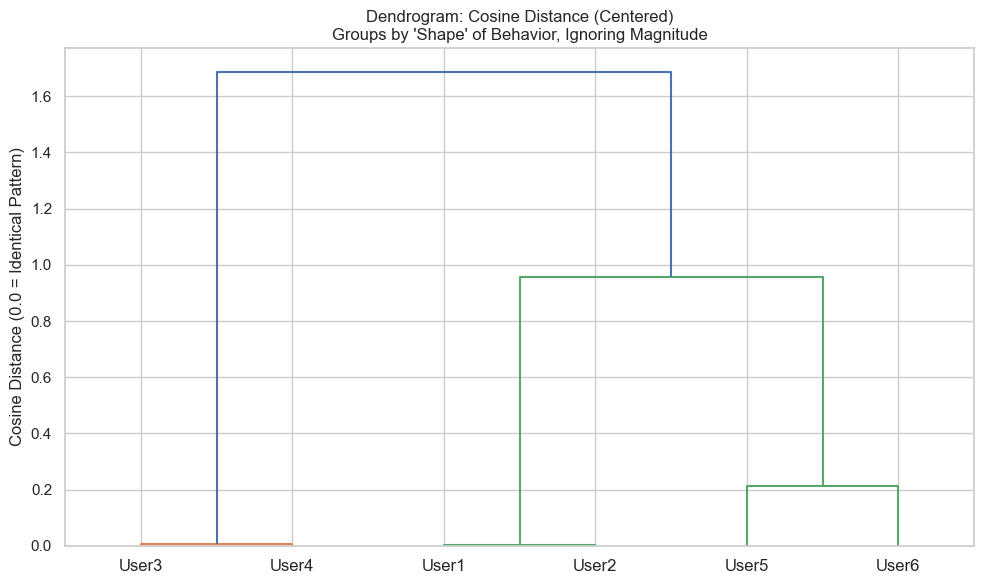

Original Data (Notice the magnitude difference between User1 and User3):
       Tech  Fashion  Home
User1    10        2     2
User2    12        1     3
User3   100       20    20
User4   120       10    30
User5     5       50     5
User6    10      100    10


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# 1. Setup Synthetic Data: Behavior Vectors
# ---------------------------------------------------------
# Scenario: 6 Users with purchase counts in 3 categories (Tech, Fashion, Home).
# We want to group them by "Interest Profile", not "Total Spend".
data = {
    # Group A: Tech Lovers (Low Volume)
    'User1': [10, 2, 2],
    'User2': [12, 1, 3],
    
    # Group B: Tech Lovers (High Volume) 
    # Note: These have the same *ratio* as Group A, but 10x the magnitude.
    'User3': [100, 20, 20],
    'User4': [120, 10, 30],
    
    # Group C: Fashion Lovers (Mixed Volume)
    # Note: Completely different ratio/pattern.
    'User5': [5, 50, 5],
    'User6': [10, 100, 10]
}

# Transpose so rows are users, columns are categories
df = pd.DataFrame(data).T
df.columns = ['Tech', 'Fashion', 'Home']

# 2. Preprocessing: Centering
# ---------------------------------------------------------
# "Centering" (subtracting the mean) converts Cosine Similarity 
# into Pearson Correlation. This normalizes for users who just 
# "rate everything higher" or "buy more in general."
scaler = StandardScaler(with_std=False) # with_std=False performs centering only
X_centered = scaler.fit_transform(df)

# 3. Clustering: Average Linkage with Cosine Metric
# ---------------------------------------------------------
# metric='cosine' calculates distance as (1 - cosine_similarity)
Z = linkage(X_centered, method='average', metric='cosine')

# 4. Visualization
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df.index, leaf_rotation=0)
plt.title("Dendrogram: Cosine Distance (Centered)\nGroups by 'Shape' of Behavior, Ignoring Magnitude")
plt.ylabel("Cosine Distance (0.0 = Identical Pattern)")
plt.tight_layout()
plt.show()

# 5. Output Data for Inspection
print("Original Data (Notice the magnitude difference between User1 and User3):")
print(df)
